In [16]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.ticker as mtick 
import matplotlib.pyplot as plt
%matplotlib inline

In [17]:
telco_base_data = pd.read_csv('Churn_Modelling_Edited.csv')

In [18]:
telco_base_data.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0


In [19]:
telco_new = telco_base_data[['Geography', 'Gender', 'Exited']]

In [20]:
telco_new.head(5)

,Geography,Gender,Exited
0,France,Female,1
1,Spain,Female,0
2,France,Female,1
3,France,Female,0
4,Spain,Female,0


In [21]:
telco_new.Exited.value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [22]:
telco_new.Exited.value_counts()/len(telco_new)*100

Exited
0    79.63
1    20.37
Name: count, dtype: float64

## Univariate Analysis

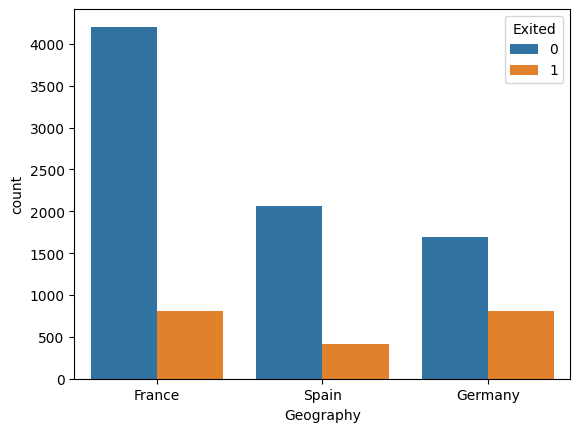

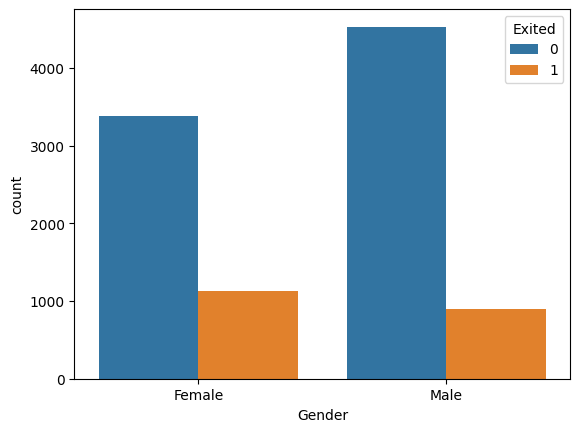

In [8]:
for i,predictor in enumerate(telco_new.drop(columns=['Exited'])):
    plt.figure()
    sns.countplot(data=telco_new,x=predictor,hue='Exited')

## Bivariate Analysis

<Axes: xlabel='Gender', ylabel='Count'>

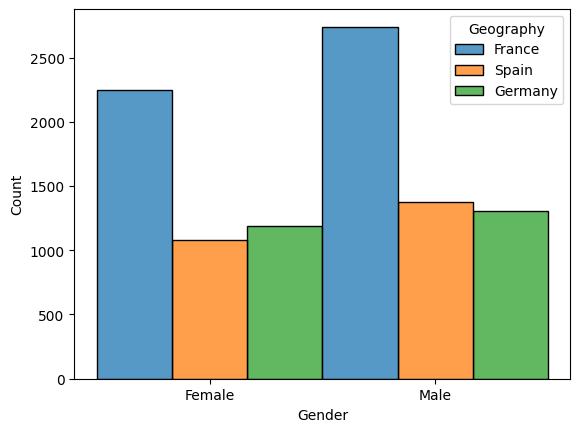

In [9]:
sns.histplot(x='Gender',hue='Geography',data=telco_new,stat="count",multiple="dodge")

In [10]:
telco_new_target1 = telco_new.loc[telco_new["Exited"]==1]

In [11]:
telco_new_target1

,Geography,Gender,Exited
0,France,Female,1
2,France,Female,1
5,Spain,Male,1
7,Germany,Female,1
16,Germany,Male,1
...,...,...,...
9981,Germany,Male,1
9982,Germany,Female,1
9991,France,Female,1
9997,France,Female,1


<Axes: xlabel='Gender', ylabel='Count'>

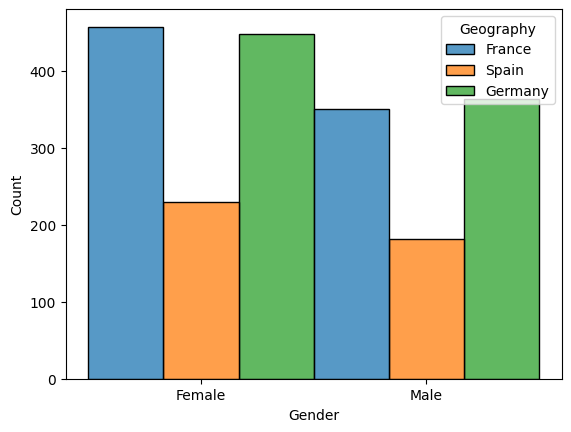

In [12]:
sns.histplot(x='Gender', hue='Geography', data=telco_new_target1, stat="count", multiple="dodge")

## Numerical Analysis

Correlation: It ranges from -1 to +1
* +1 --> Positive Correlation
* -1 --> Negative Correlation
* ~0 --> No Correlation

In [25]:
telco_base_data.corr(numeric_only=True)

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,1.000000,0.004202,0.005840,0.001694,-0.006495,-0.009067,0.007246,0.000599,0.012044,-0.005988,-0.016571
CustomerId,0.004202,1.000000,0.005308,0.011447,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248
CreditScore,0.005840,0.005308,1.000000,-0.004839,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,0.001694,0.011447,-0.004839,1.000000,-0.013109,0.027729,-0.026877,-0.016218,0.084153,-0.007919,0.287714
Tenure,-0.006495,-0.014883,0.000842,-0.013109,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,-0.009067,-0.012419,0.006268,0.027729,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.007246,0.016972,0.012238,-0.026877,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,0.000599,-0.014025,-0.005458,-0.016218,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.012044,0.001665,0.025651,0.084153,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.005988,0.015271,-0.001384,-0.007919,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097


<Axes: >

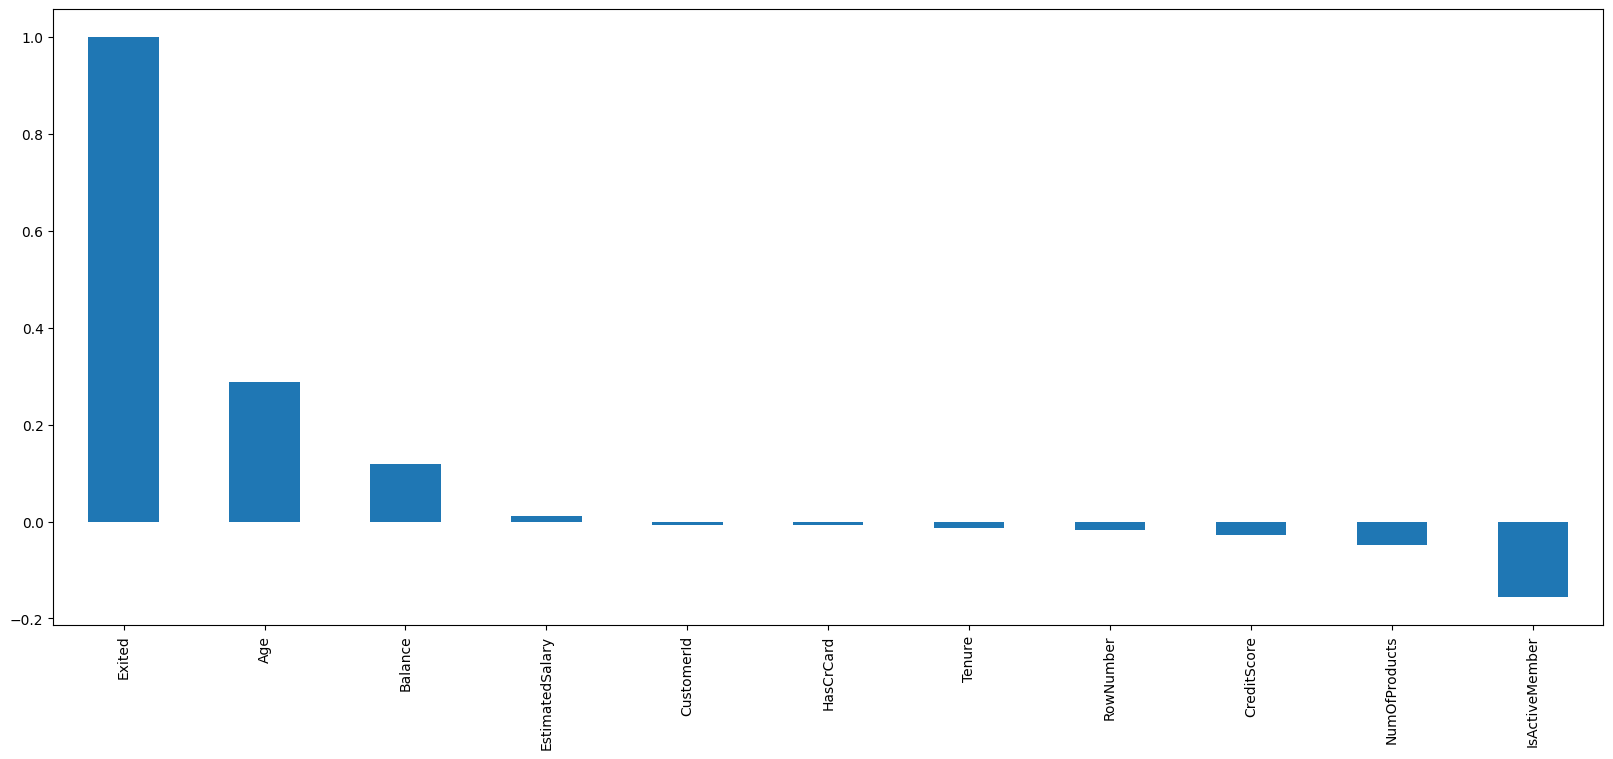

In [29]:
plt.figure(figsize=(20,8))
telco_base_data.corr(numeric_only=True)['Exited'].sort_values(ascending=False).plot(kind='bar')

<Axes: >

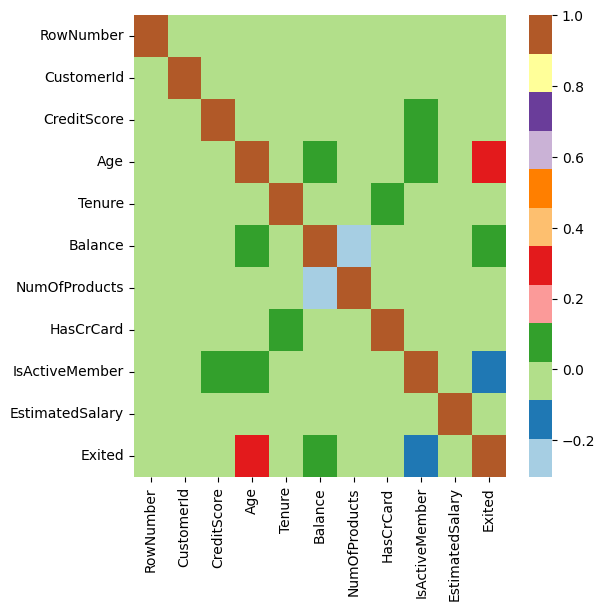

In [33]:
plt.figure(figsize=(6,6))
sns.heatmap(telco_base_data.corr(numeric_only=True), cmap='Paired')

<Axes: xlabel='Age'>

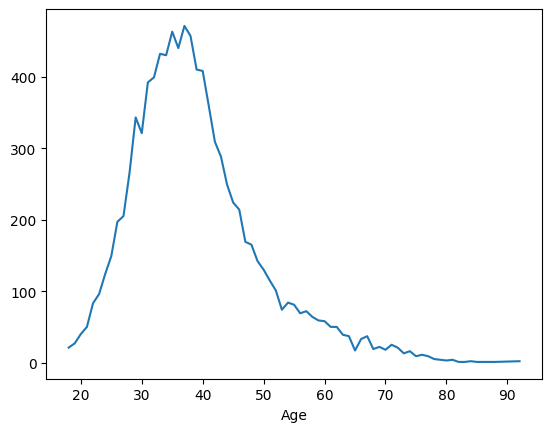

In [36]:
telco_base_data['Age'].value_counts().sort_index(ascending=True).plot()

In [37]:
telco_base_data_1 = telco_base_data.loc[telco_base_data["Exited"]==1]

<Axes: xlabel='Age'>

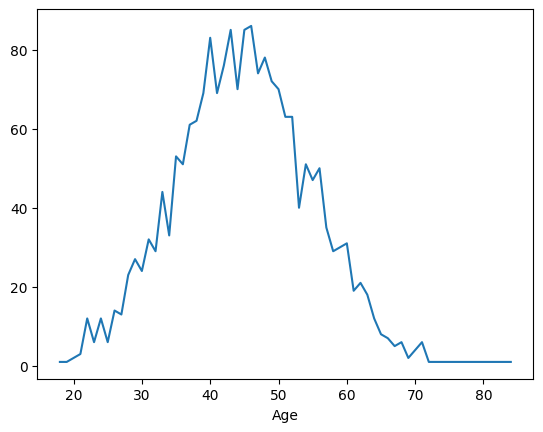

In [38]:
telco_base_data_1['Age'].value_counts().sort_index(ascending=True).plot()

C:\Users\Sandesh Dhakal\AppData\Local\Temp\ipykernel_29004\1473130130.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(telco_base_data.Age[(telco_base_data["Exited"]==0)],
C:\Users\Sandesh Dhakal\AppData\Local\Temp\ipykernel_29004\1473130130.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(telco_base_data.Age[(telco_base_data["Exited"]==1)],


Text(0.5, 1.0, 'Age by churn')

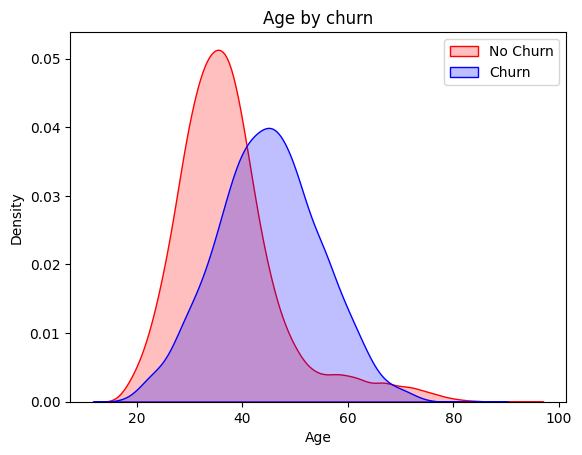

In [40]:
Tot = sns.kdeplot(telco_base_data.Age[(telco_base_data["Exited"]==0)],
                  color="Red", shade=True)
Tot = sns.kdeplot(telco_base_data.Age[(telco_base_data["Exited"]==1)],
                  color="Blue", shade=True)
Tot.legend(["No Churn", "Churn"], loc='upper right')
Tot.set_ylabel('Density')
Tot.set_xlabel('Age')
Tot.set_title('Age by churn')
     

C:\Users\Sandesh Dhakal\AppData\Local\Temp\ipykernel_29004\3581521652.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(telco_base_data.Tenure[(telco_base_data["Exited"]==0)],
C:\Users\Sandesh Dhakal\AppData\Local\Temp\ipykernel_29004\3581521652.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(telco_base_data.Tenure[(telco_base_data["Exited"]==1)],


Text(0.5, 1.0, 'Tenure by churn')

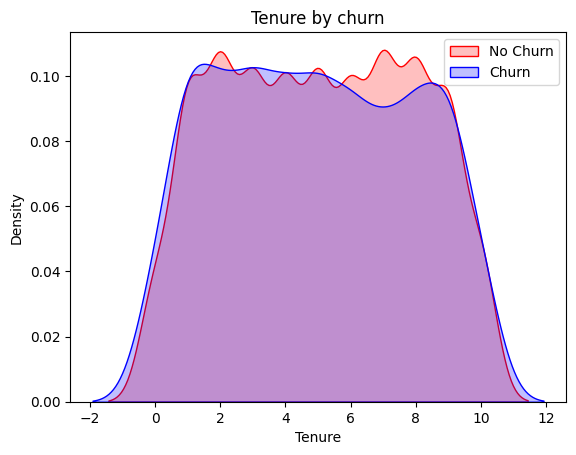

In [41]:
Tot = sns.kdeplot(telco_base_data.Tenure[(telco_base_data["Exited"]==0)],
                  color="Red", shade=True)
Tot = sns.kdeplot(telco_base_data.Tenure[(telco_base_data["Exited"]==1)],
                  color="Blue", shade=True)
Tot.legend(["No Churn", "Churn"], loc='upper right')
Tot.set_ylabel('Density')
Tot.set_xlabel('Tenure')
Tot.set_title('Tenure by churn')

C:\Users\Sandesh Dhakal\AppData\Local\Temp\ipykernel_29004\1119010408.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(telco_base_data.Balance[(telco_base_data["Exited"]==0)],
C:\Users\Sandesh Dhakal\AppData\Local\Temp\ipykernel_29004\1119010408.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(telco_base_data.Balance[(telco_base_data["Exited"]==1)],


Text(0.5, 1.0, 'Balance by churn')

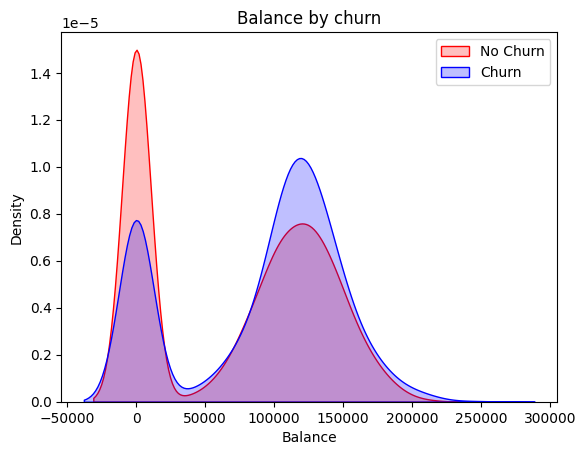

In [42]:

Tot = sns.kdeplot(telco_base_data.Balance[(telco_base_data["Exited"]==0)],
                  color="Red", shade=True)
Tot = sns.kdeplot(telco_base_data.Balance[(telco_base_data["Exited"]==1)],
                  color="Blue", shade=True)
Tot.legend(["No Churn", "Churn"], loc='upper right')
Tot.set_ylabel('Density')
Tot.set_xlabel('Balance')
Tot.set_title('Balance by churn')